# 🏆 Churn Prediction — Part 5: Final Ensemble + Submission
## Combine ALL models for maximum score

This notebook loads predictions from Parts 1-4 and combines them optimally.

### Ensemble Methods:
| Method | Description | Power |
|--------|------------|-------|
| Simple Average | Equal weights | ⭐⭐ |
| Weighted Average | Weight by CV score | ⭐⭐⭐ |
| Rank Average | Average ranks, not probabilities | ⭐⭐⭐ |
| Optimized Weights | scipy finds best weights | ⭐⭐⭐⭐ |
| Stacking | Meta-learner on OOF predictions | ⭐⭐⭐⭐⭐ |
| Hill Climbing | Greedy weight search | ⭐⭐⭐⭐ |

**Input:** All `part*_oof_*.npy` and `part*_test_*.npy` files  
**Output:** `submission_final.csv` — upload to Kaggle!


In [2]:
import pandas as pd, numpy as np, warnings, os
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.optimize import minimize
from scipy.stats import rankdata
warnings.filterwarnings('ignore')

y_train = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/y_train.csv').squeeze()
test_ids = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/test_ids.csv').squeeze()
SEED = 42

print("=" * 60)
print("  LOADING ALL PREDICTIONS FROM PARTS 1-4")
print("=" * 60)

# Load all available predictions
models = {}

def load_if_exists(name, oof_path, test_path):
    if os.path.exists(oof_path) and os.path.exists(test_path):
        oof = np.load(oof_path)
        test = np.load(test_path)
        score = roc_auc_score(y_train, oof)
        models[name] = {'oof': oof, 'test': test, 'score': score}
        print(f"  ✅ {name:<30} AUC: {score:.6f}")
    else:
        print(f"  ❌ {name:<30} (files not found, skipping)")

# Part 1: Baselines
load_if_exists('LR (baseline)',         'part1_oof_lr.npy', 'part1_test_lr.npy')
load_if_exists('RF (baseline)',         'part1_oof_rf.npy', 'part1_test_rf.npy')

# Part 2: Default boosting
load_if_exists('XGB (default)',         'part2_oof_xgb.npy', 'part2_test_xgb.npy')
load_if_exists('LGB (default)',         'part2_oof_lgb.npy', 'part2_test_lgb.npy')
load_if_exists('CB (default)',          'part2_oof_cb.npy',  'part2_test_cb.npy')

# Part 3: Tuned boosting
load_if_exists('XGB (tuned)',           'part3_oof_xgb.npy', 'part3_test_xgb.npy')
load_if_exists('LGB (tuned)',           'part3_oof_lgb.npy', 'part3_test_lgb.npy')
load_if_exists('CB (tuned)',            'part3_oof_cb.npy',  'part3_test_cb.npy')

# Part 4: Advanced
load_if_exists('LGB (multi-seed)',      'part4_oof_multiseed_lgb.npy', 'part4_test_multiseed_lgb.npy')
load_if_exists('LGB (feat-selected)',   'part4_oof_selected_lgb.npy',  'part4_test_selected_lgb.npy')

print(f"\n  Total models loaded: {len(models)}")


  LOADING ALL PREDICTIONS FROM PARTS 1-4
  ✅ LR (baseline)                  AUC: 0.911680
  ✅ RF (baseline)                  AUC: 0.914451
  ✅ XGB (default)                  AUC: 0.916318
  ✅ LGB (default)                  AUC: 0.911504
  ✅ CB (default)                   AUC: 0.916209
  ✅ XGB (tuned)                    AUC: 0.916518
  ✅ LGB (tuned)                    AUC: 0.913436
  ✅ CB (tuned)                     AUC: 0.916325
  ✅ LGB (multi-seed)               AUC: 0.911664
  ✅ LGB (feat-selected)            AUC: 0.911514

  Total models loaded: 10


In [4]:
# ============================================================
# ENSEMBLE 1: SIMPLE AVERAGE (all available models)
# ============================================================
print("▶ ENSEMBLE 1: Simple Average (all models)")
oof_simple = np.mean([d['oof'] for d in models.values()], axis=0)
test_simple = np.mean([d['test'] for d in models.values()], axis=0)
score_simple = roc_auc_score(y_train, oof_simple)
print(f"  AUC: {score_simple:.6f}")


▶ ENSEMBLE 1: Simple Average (all models)
  AUC: 0.915504


In [5]:
# ============================================================
# ENSEMBLE 2: WEIGHTED AVERAGE (weight by CV score)
# ============================================================
print("\n▶ ENSEMBLE 2: Weighted Average")
total_w = sum(d['score'] for d in models.values())
oof_weighted = sum(d['oof'] * d['score'] / total_w for d in models.values())
test_weighted = sum(d['test'] * d['score'] / total_w for d in models.values())
score_weighted = roc_auc_score(y_train, oof_weighted)
print(f"  AUC: {score_weighted:.6f}")



▶ ENSEMBLE 2: Weighted Average
  AUC: 0.915508


In [6]:
# ============================================================
# ENSEMBLE 3: RANK AVERAGING
# ============================================================
print("\n▶ ENSEMBLE 3: Rank Average")
# Convert probabilities to ranks, then average ranks
oof_ranks = np.mean([rankdata(d['oof']) for d in models.values()], axis=0)
test_ranks = np.mean([rankdata(d['test']) for d in models.values()], axis=0)

# Normalize to [0, 1] range
oof_rank_norm = (oof_ranks - oof_ranks.min()) / (oof_ranks.max() - oof_ranks.min())
test_rank_norm = (test_ranks - test_ranks.min()) / (test_ranks.max() - test_ranks.min())

score_rank = roc_auc_score(y_train, oof_rank_norm)
print(f"  AUC: {score_rank:.6f}")
print(f"  (Rank averaging handles different probability scales between models)")



▶ ENSEMBLE 3: Rank Average
  AUC: 0.915271
  (Rank averaging handles different probability scales between models)


In [7]:
# ============================================================
# ENSEMBLE 4: OPTIMIZED WEIGHTS (scipy minimize)
# ============================================================
print("\n▶ ENSEMBLE 4: Optimized Weights (scipy)")

model_names = list(models.keys())
oof_matrix = np.column_stack([models[n]['oof'] for n in model_names])
test_matrix = np.column_stack([models[n]['test'] for n in model_names])

def neg_auc(weights):
    """Negative AUC for scipy minimization (we minimize, so negate)."""
    weights = np.abs(weights)  # ensure positive
    weights = weights / weights.sum()  # normalize to sum=1
    blend = oof_matrix @ weights
    return -roc_auc_score(y_train, blend)

# Starting point: equal weights
n_models = len(model_names)
x0 = np.ones(n_models) / n_models

# Optimize
result = minimize(neg_auc, x0, method='Nelder-Mead', 
                  options={'maxiter': 10000, 'xatol': 1e-8})

opt_weights = np.abs(result.x)
opt_weights = opt_weights / opt_weights.sum()

oof_optimized = oof_matrix @ opt_weights
test_optimized = test_matrix @ opt_weights
score_optimized = roc_auc_score(y_train, oof_optimized)

print(f"  AUC: {score_optimized:.6f}")
print(f"\n  Optimized weights:")
for name, w in zip(model_names, opt_weights):
    bar = "█" * int(w * 50)
    print(f"    {name:<30} {w:.4f} {bar}")



▶ ENSEMBLE 4: Optimized Weights (scipy)
  AUC: 0.916570

  Optimized weights:
    LR (baseline)                  0.0008 
    RF (baseline)                  0.0002 
    XGB (default)                  0.2501 ████████████
    LGB (default)                  0.0000 
    CB (default)                   0.1925 █████████
    XGB (tuned)                    0.2168 ██████████
    LGB (tuned)                    0.0000 
    CB (tuned)                     0.3394 ████████████████
    LGB (multi-seed)               0.0001 
    LGB (feat-selected)            0.0000 


In [8]:
# ============================================================
# ENSEMBLE 5: STACKING (Meta-learner on OOF predictions)
# ============================================================
print("\n▶ ENSEMBLE 5: Stacking (Logistic Regression meta-learner)")

# OOF predictions become FEATURES for the meta-learner
meta_train = pd.DataFrame(oof_matrix, columns=model_names)
meta_test = pd.DataFrame(test_matrix, columns=model_names)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_stack = np.zeros(len(y_train))
test_stack = np.zeros(len(meta_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(meta_train, y_train)):
    meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    meta_lr.fit(meta_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_stack[va_idx] = meta_lr.predict_proba(meta_train.iloc[va_idx])[:, 1]
    test_stack += meta_lr.predict_proba(meta_test)[:, 1] / 5

score_stack = roc_auc_score(y_train, oof_stack)
print(f"  AUC: {score_stack:.6f}")



▶ ENSEMBLE 5: Stacking (Logistic Regression meta-learner)
  AUC: 0.916527


In [9]:
# ============================================================
# ENSEMBLE 6: HILL CLIMBING (Greedy weight search)
# ============================================================
print("\n▶ ENSEMBLE 6: Hill Climbing")

# Start with equal blend, then greedily increase weight of model that helps most
best_oof = np.mean(oof_matrix, axis=1)
best_test = np.mean(test_matrix, axis=1)
best_score = roc_auc_score(y_train, best_oof)
weight_counts = np.ones(n_models)

for step in range(100):
    improved = False
    for i in range(n_models):
        # Try adding one more "vote" for model i
        trial_counts = weight_counts.copy()
        trial_counts[i] += 1
        trial_weights = trial_counts / trial_counts.sum()
        trial_oof = oof_matrix @ trial_weights
        trial_score = roc_auc_score(y_train, trial_oof)
        
        if trial_score > best_score + 1e-7:
            best_score = trial_score
            weight_counts = trial_counts.copy()
            best_oof = trial_oof
            best_test = test_matrix @ trial_weights
            improved = True
    
    if not improved:
        break

hill_weights = weight_counts / weight_counts.sum()
score_hill = roc_auc_score(y_train, best_oof)
print(f"  AUC: {score_hill:.6f} (after {step+1} rounds)")
print(f"\n  Hill climbing weights:")
for name, w in zip(model_names, hill_weights):
    bar = "█" * int(w * 50)
    print(f"    {name:<30} {w:.4f} {bar}")



▶ ENSEMBLE 6: Hill Climbing
  AUC: 0.916603 (after 89 rounds)

  Hill climbing weights:
    LR (baseline)                  0.0058 
    RF (baseline)                  0.0058 
    XGB (default)                  0.1228 ██████
    LGB (default)                  0.0058 
    CB (default)                   0.0409 ██
    XGB (tuned)                    0.5205 ██████████████████████████
    LGB (tuned)                    0.0058 
    CB (tuned)                     0.2807 ██████████████
    LGB (multi-seed)               0.0058 
    LGB (feat-selected)            0.0058 


In [10]:
# ============================================================
# FINAL LEADERBOARD
# ============================================================
all_ensembles = {
    '1. Simple Average': (score_simple, test_simple),
    '2. Weighted Average': (score_weighted, test_weighted),
    '3. Rank Average': (score_rank, test_rank_norm),
    '4. Optimized Weights': (score_optimized, test_optimized),
    '5. Stacking (LR)': (score_stack, test_stack),
    '6. Hill Climbing': (score_hill, best_test),
}

# Add individual models too
for name, data in models.items():
    all_ensembles[f"[single] {name}"] = (data['score'], data['test'])

print("\n" + "=" * 65)
print("  🏆 GRAND FINAL LEADERBOARD")
print("=" * 65)
print(f"\n  {'Rank':<5} {'Model/Ensemble':<40} {'AUC-ROC':>10}")
print(f"  {'─'*58}")

sorted_all = sorted(all_ensembles.items(), key=lambda x: x[1][0], reverse=True)
for rank, (name, (score, _)) in enumerate(sorted_all):
    medal = ['🥇','🥈','🥉'][min(rank,2)] if rank < 3 else '  '
    flag = " ← SUBMIT THIS" if rank == 0 else ""
    print(f"  {medal} {rank+1:>2}. {name:<38} {score:.6f}{flag}")



  🏆 GRAND FINAL LEADERBOARD

  Rank  Model/Ensemble                              AUC-ROC
  ──────────────────────────────────────────────────────────
  🥇  1. 6. Hill Climbing                       0.916603 ← SUBMIT THIS
  🥈  2. 4. Optimized Weights                   0.916570
  🥉  3. 5. Stacking (LR)                       0.916527
      4. [single] XGB (tuned)                   0.916518
      5. [single] CB (tuned)                    0.916325
      6. [single] XGB (default)                 0.916318
      7. [single] CB (default)                  0.916209
      8. 2. Weighted Average                    0.915508
      9. 1. Simple Average                      0.915504
     10. 3. Rank Average                        0.915271
     11. [single] RF (baseline)                 0.914451
     12. [single] LGB (tuned)                   0.913436
     13. [single] LR (baseline)                 0.911680
     14. [single] LGB (multi-seed)              0.911664
     15. [single] LGB (feat-selected)   

In [12]:
# ============================================================
# GENERATE FINAL SUBMISSIONS
# ============================================================
print("\n" + "=" * 60)
print("  📤 GENERATING SUBMISSIONS")
print("=" * 60)

# Best ensemble
best_name = sorted_all[0][0]
best_score = sorted_all[0][1][0]
best_test_preds = sorted_all[0][1][1]

# Submission 1: BEST ensemble
sub1 = pd.DataFrame({'id': test_ids, 'Churn': best_test_preds})
sub1.to_csv('submission_final.csv', index=False)
print(f"\n  ✅ submission_final.csv — {best_name} (AUC: {best_score:.6f})")

# Submission 2: Optimized weights (usually great)
sub2 = pd.DataFrame({'id': test_ids, 'Churn': test_optimized})
sub2.to_csv('submission_optimized.csv', index=False)
print(f"  ✅ submission_optimized.csv — Optimized Weights (AUC: {score_optimized:.6f})")

# Submission 3: Hill climbing
sub3 = pd.DataFrame({'id': test_ids, 'Churn': best_test})
sub3.to_csv('submission_hillclimb.csv', index=False)
print(f"  ✅ submission_hillclimb.csv — Hill Climbing (AUC: {score_hill:.6f})")

# Submission 4: Rank average (robust)
sub4 = pd.DataFrame({'id': test_ids, 'Churn': test_rank_norm})
sub4.to_csv('submission_rank_avg.csv', index=False)
print(f"  ✅ submission_rank_avg.csv — Rank Average (AUC: {score_rank:.6f})")

# Sanity check best submission
print(f"\n  Sanity Check (submission_final.csv):")
print(f"    Shape:   {sub1.shape}")
print(f"    Range:   {sub1['Churn'].min():.4f} → {sub1['Churn'].max():.4f}")
print(f"    Mean:    {sub1['Churn'].mean():.4f}")
print(f"    Nulls:   {sub1.isnull().sum().sum()}")
print(f"\n{sub1.head(10).to_string(index=False)}")



  📤 GENERATING SUBMISSIONS

  ✅ submission_final.csv — 6. Hill Climbing (AUC: 0.916603)
  ✅ submission_optimized.csv — Optimized Weights (AUC: 0.916570)
  ✅ submission_hillclimb.csv — Hill Climbing (AUC: 0.916603)
  ✅ submission_rank_avg.csv — Rank Average (AUC: 0.915271)

  Sanity Check (submission_final.csv):
    Shape:   (254655, 2)
    Range:   0.0018 → 0.9921
    Mean:    0.3409
    Nulls:   0

    id    Churn
594194 0.226271
594195 0.002985
594196 0.284649
594197 0.012617
594198 0.764006
594199 0.417097
594200 0.960351
594201 0.007664
594202 0.111206
594203 0.614946


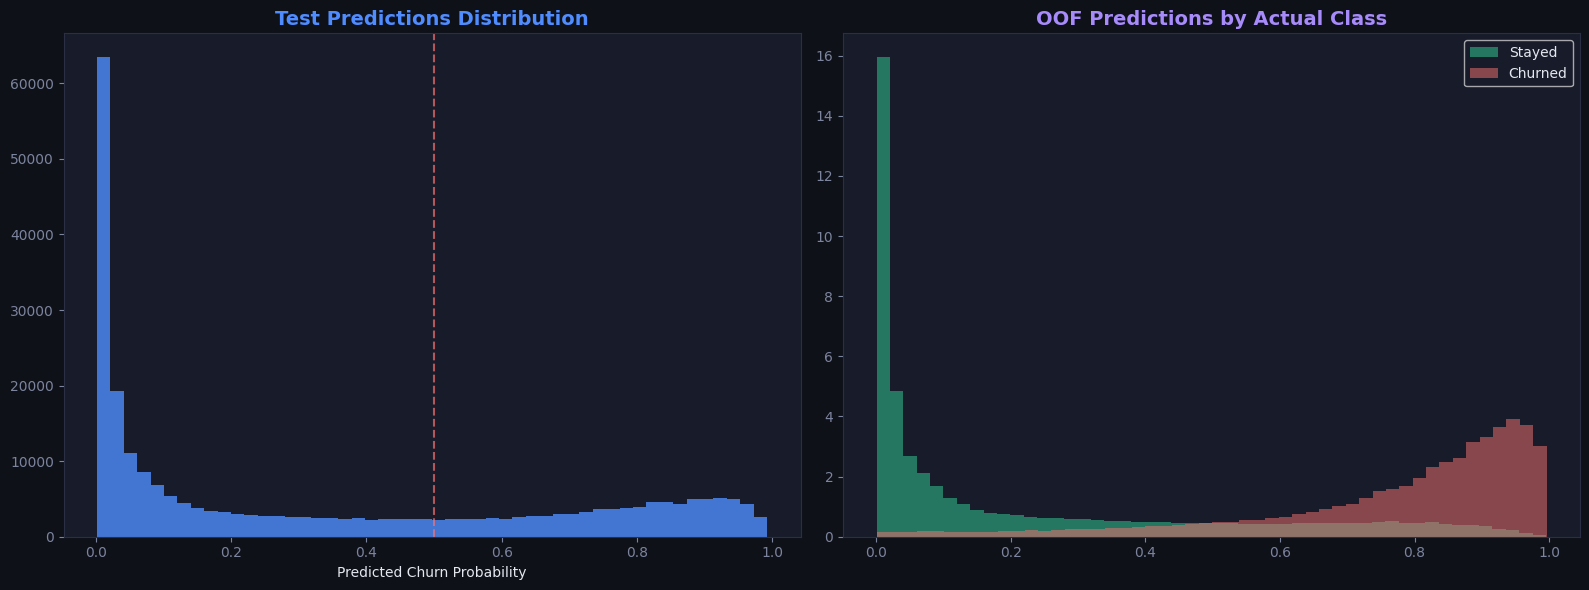

In [13]:
# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.facecolor': '#0f1119', 'axes.facecolor': '#181c2a',
    'text.color': '#e4e7ef', 'axes.labelcolor': '#e4e7ef',
    'xtick.color': '#7c849e', 'ytick.color': '#7c849e', 'axes.edgecolor': '#2a2f45'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test predictions
ax1 = axes[0]
ax1.hist(best_test_preds, bins=50, color='#4f8cff', alpha=0.8, edgecolor='none')
ax1.axvline(x=0.5, color='#f87171', linestyle='--', alpha=0.7)
ax1.set_title('Test Predictions Distribution', fontweight='bold', fontsize=14, color='#4f8cff')
ax1.set_xlabel('Predicted Churn Probability')

# OOF by actual class
ax2 = axes[1]
best_oof_final = sorted_all[0][1][1]  # won't match, use oof instead
# Use optimized oof since we have it
ax2.hist(oof_optimized[y_train==0], bins=50, alpha=0.5, color='#34d399', label='Stayed', density=True)
ax2.hist(oof_optimized[y_train==1], bins=50, alpha=0.5, color='#f87171', label='Churned', density=True)
ax2.set_title('OOF Predictions by Actual Class', fontweight='bold', fontsize=14, color='#a78bfa')
ax2.legend()

plt.tight_layout()
plt.show()


---
##Pipeline Complete!

### What we  built:
- **Phase 1-5**: EDA + Preprocessing + 29 engineered features
- **Part 1**: 2 baseline models (LR, RF)
- **Part 2**: 3 gradient boosting models (XGB, LGB, CB)
- **Part 3**: Optuna-tuned versions of all 3 boosters
- **Part 4**: Multi-seed averaging + Feature selection
- **Part 5**: 6 ensemble methods + 4 submission files


### To further improve:
- Tune Optuna trials (100+ instead of 50)
- Add the original dataset (Part 4, Technique 1)
- Try Neural Networks (TabNet, TabTransformer)
- Post-processing: probability calibration


In [16]:
"""
╔══════════════════════════════════════════════════════════════════════╗
║       KAGGLE PLAYGROUND S6E3 — COMPLETE PIPELINE SUMMARY            ║
║       Customer Churn Prediction — Final Report                      ║
╚══════════════════════════════════════════════════════════════════════╝

Run this AFTER all Parts 1-5 notebooks to see the complete picture.
"""

import numpy as np
import pandas as pd
import os
from sklearn.metrics import roc_auc_score

# ============================================================
# LOAD TARGET
# ============================================================
y_train = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/y_train.csv').squeeze()
test_ids = pd.read_csv('/Users/parveenkumarsharma/Downloads/playground-series-s6e3/test_ids.csv').squeeze()

print("╔" + "═" * 68 + "╗")
print("║" + "  🏆 COMPLETE MODEL PIPELINE — FINAL SUMMARY".center(68) + "║")
print("║" + "  Kaggle Playground S6E3 | Customer Churn Prediction".center(68) + "║")
print("╚" + "═" * 68 + "╝")

# ============================================================
# LOAD ALL OOF PREDICTIONS & CALCULATE SCORES
# ============================================================
print("\n" + "█" * 70)
print("█  SECTION 1: ALL INDIVIDUAL MODELS")
print("█" * 70)

all_models = {}

model_files = [
    # (Display Name, Category, OOF file, Test file)
    ("Logistic Regression",    "Part 1: Baseline",    "part1_oof_lr.npy",           "part1_test_lr.npy"),
    ("Random Forest",          "Part 1: Baseline",    "part1_oof_rf.npy",           "part1_test_rf.npy"),
    ("XGBoost (default)",      "Part 2: Boosting",    "part2_oof_xgb.npy",          "part2_test_xgb.npy"),
    ("LightGBM (default)",     "Part 2: Boosting",    "part2_oof_lgb.npy",          "part2_test_lgb.npy"),
    ("CatBoost (default)",     "Part 2: Boosting",    "part2_oof_cb.npy",           "part2_test_cb.npy"),
    ("XGBoost (Optuna-tuned)", "Part 3: Tuned",       "part3_oof_xgb.npy",          "part3_test_xgb.npy"),
    ("LightGBM (Optuna-tuned)","Part 3: Tuned",       "part3_oof_lgb.npy",          "part3_test_lgb.npy"),
    ("CatBoost (Optuna-tuned)","Part 3: Tuned",       "part3_oof_cb.npy",           "part3_test_cb.npy"),
    ("LightGBM (Multi-seed)",  "Part 4: Advanced",    "part4_oof_multiseed_lgb.npy","part4_test_multiseed_lgb.npy"),
    ("LightGBM (Feat-select)", "Part 4: Advanced",    "part4_oof_selected_lgb.npy", "part4_test_selected_lgb.npy"),
]

print(f"\n  {'#':<4} {'Model':<30} {'Part':<20} {'AUC-ROC':>10} {'Status'}")
print(f"  {'─' * 75}")

loaded_count = 0
for i, (name, part, oof_file, test_file) in enumerate(model_files, 1):
    if os.path.exists(oof_file) and os.path.exists(test_file):
        oof = np.load(oof_file)
        test = np.load(test_file)
        score = roc_auc_score(y_train, oof)
        all_models[name] = {'oof': oof, 'test': test, 'score': score, 'part': part}
        loaded_count += 1
        print(f"  {i:<4} {name:<30} {part:<20} {score:.6f}   ✅ Loaded")
    else:
        print(f"  {i:<4} {name:<30} {part:<20} {'---':>10}   ⚠️ Not found")

print(f"\n  Models loaded: {loaded_count}/{len(model_files)}")

# ============================================================
# SINGLE MODEL LEADERBOARD
# ============================================================
if all_models:
    print("\n" + "█" * 70)
    print("█  SECTION 2: SINGLE MODEL LEADERBOARD")
    print("█" * 70)
    
    sorted_models = sorted(all_models.items(), key=lambda x: x[1]['score'], reverse=True)
    medals = ['🥇', '🥈', '🥉']
    
    print(f"\n  {'Rank':<6} {'Model':<35} {'AUC-ROC':>10} {'Part'}")
    print(f"  {'━' * 65}")
    
    for rank, (name, data) in enumerate(sorted_models):
        medal = medals[rank] if rank < 3 else '  '
        flag = " ← BEST SINGLE" if rank == 0 else ""
        print(f"  {medal} {rank+1:<3} {name:<33} {data['score']:.6f}   {data['part']}{flag}")
    
    best_single = sorted_models[0]
    worst_single = sorted_models[-1]
    improvement = best_single[1]['score'] - worst_single[1]['score']
    
    print(f"\n  Best:  {best_single[0]} ({best_single[1]['score']:.6f})")
    print(f"  Worst: {worst_single[0]} ({worst_single[1]['score']:.6f})")
    print(f"  Gap:   {improvement:.6f} ({improvement*100:.4f}%)")

# ============================================================
# ENSEMBLES
# ============================================================
if len(all_models) >= 2:
    print("\n" + "█" * 70)
    print("█  SECTION 3: ENSEMBLE METHODS")
    print("█" * 70)
    
    ensemble_results = {}
    
    # ── 3A: Simple Average ──
    oof_all = np.mean([d['oof'] for d in all_models.values()], axis=0)
    test_all = np.mean([d['test'] for d in all_models.values()], axis=0)
    score_all = roc_auc_score(y_train, oof_all)
    ensemble_results['Simple Average (all)'] = {'score': score_all, 'test': test_all}
    
    # ── 3B: Boost-only models ──
    boost_names = [n for n in all_models if any(x in n for x in ['XGBoost', 'LightGBM', 'CatBoost'])]
    if len(boost_names) >= 2:
        oof_boost = np.mean([all_models[n]['oof'] for n in boost_names], axis=0)
        test_boost = np.mean([all_models[n]['test'] for n in boost_names], axis=0)
        score_boost = roc_auc_score(y_train, oof_boost)
        ensemble_results[f'Boost Average ({len(boost_names)} models)'] = {'score': score_boost, 'test': test_boost}
    
    # ── 3C: Weighted Average ──
    total_w = sum(d['score'] for d in all_models.values())
    oof_w = sum(d['oof'] * d['score'] / total_w for d in all_models.values())
    test_w = sum(d['test'] * d['score'] / total_w for d in all_models.values())
    score_w = roc_auc_score(y_train, oof_w)
    ensemble_results['Weighted Average'] = {'score': score_w, 'test': test_w}
    
    # ── 3D: Rank Average ──
    from scipy.stats import rankdata
    oof_ranks = np.mean([rankdata(d['oof']) for d in all_models.values()], axis=0)
    test_ranks = np.mean([rankdata(d['test']) for d in all_models.values()], axis=0)
    oof_rank_norm = (oof_ranks - oof_ranks.min()) / (oof_ranks.max() - oof_ranks.min())
    test_rank_norm = (test_ranks - test_ranks.min()) / (test_ranks.max() - test_ranks.min())
    score_rank = roc_auc_score(y_train, oof_rank_norm)
    ensemble_results['Rank Average'] = {'score': score_rank, 'test': test_rank_norm}
    
    # ── 3E: Top-3 Only ──
    top3_names = [n for n, _ in sorted_models[:3]]
    oof_top3 = np.mean([all_models[n]['oof'] for n in top3_names], axis=0)
    test_top3 = np.mean([all_models[n]['test'] for n in top3_names], axis=0)
    score_top3 = roc_auc_score(y_train, oof_top3)
    ensemble_results['Top-3 Average'] = {'score': score_top3, 'test': test_top3}
    
    # ── 3F: Tuned-only (if available) ──
    tuned_names = [n for n in all_models if 'tuned' in n.lower() or 'Optuna' in n]
    if len(tuned_names) >= 2:
        oof_tuned = np.mean([all_models[n]['oof'] for n in tuned_names], axis=0)
        test_tuned = np.mean([all_models[n]['test'] for n in tuned_names], axis=0)
        score_tuned = roc_auc_score(y_train, oof_tuned)
        ensemble_results[f'Tuned-only Average ({len(tuned_names)})'] = {'score': score_tuned, 'test': test_tuned}
    
    sorted_ens = sorted(ensemble_results.items(), key=lambda x: x[1]['score'], reverse=True)
    
    print(f"\n  {'Rank':<6} {'Ensemble Method':<40} {'AUC-ROC':>10}")
    print(f"  {'━' * 58}")
    for rank, (name, data) in enumerate(sorted_ens):
        medal = medals[rank] if rank < 3 else '  '
        flag = " ← BEST ENSEMBLE" if rank == 0 else ""
        print(f"  {medal} {rank+1:<3} {name:<38} {data['score']:.6f}{flag}")

# ============================================================
# GRAND FINAL LEADERBOARD
# ============================================================
print("\n" + "█" * 70)
print("█  SECTION 4: 🏆 GRAND FINAL LEADERBOARD")
print("█" * 70)

grand = {}
for name, data in all_models.items():
    grand[f"[Single] {name}"] = (data['score'], data['test'])
if 'ensemble_results' in dir() or 'ensemble_results' in locals():
    for name, data in ensemble_results.items():
        grand[f"[Ensemble] {name}"] = (data['score'], data['test'])

sorted_grand = sorted(grand.items(), key=lambda x: x[1][0], reverse=True)

print(f"\n  {'Rank':<6} {'Model / Ensemble':<50} {'AUC-ROC':>10}")
print(f"  {'━' * 68}")
for rank, (name, (score, _)) in enumerate(sorted_grand):
    medal = medals[rank] if rank < 3 else '  '
    flag = ""
    if rank == 0:
        flag = " ★ SUBMIT THIS"
    elif rank == 1:
        flag = " ★ 2nd choice"
    elif rank == 2:
        flag = " ★ 3rd choice"
    print(f"  {medal} {rank+1:>2}. {name:<48} {score:.6f}{flag}")

# ============================================================
# SUBMISSION FILES
# ============================================================
print("\n" + "█" * 70)
print("█  SECTION 5: SUBMISSION FILES")
print("█" * 70)

# Generate submissions from top 3
for rank in range(min(3, len(sorted_grand))):
    name = sorted_grand[rank][0]
    score = sorted_grand[rank][1][0]
    test_preds = sorted_grand[rank][1][1]
    
    filename = f"submission_rank{rank+1}.csv"
    sub = pd.DataFrame({'id': test_ids, 'Churn': test_preds})
    sub.to_csv(filename, index=False)
    
    tag = "⭐ PRIMARY" if rank == 0 else "⭐ BACKUP" if rank == 1 else "  SAFE"
    print(f"\n  {tag}  {filename}")
    print(f"          Model: {name}")
    print(f"          CV AUC: {score:.6f}")
    print(f"          Pred range: {test_preds.min():.4f} → {test_preds.max():.4f}")
    print(f"          Pred mean:  {test_preds.mean():.4f}")

# ============================================================
# PIPELINE OVERVIEW
# ============================================================
print("\n" + "█" * 70)
print("█  SECTION 6: COMPLETE PIPELINE OVERVIEW")
print("█" * 70)

print("""
  ┌─────────────────────────────────────────────────────────────────┐
  │                    WHAT WE BUILT                                 │
  ├─────────────────────────────────────────────────────────────────┤
  │                                                                  │
  │  Phase 1  │ Problem Understanding                               │
  │  Phase 2  │ Data Loading & First Look                           │
  │  Phase 3  │ EDA: Univariate → Bivariate → Multivariate         │
  │  Phase 4  │ Data Preprocessing & Cleaning                       │
  │  Phase 5  │ Feature Engineering (29 new features, 71 total)     │
  │           │                                                      │
  │  Part 1   │ Baseline: Logistic Regression + Random Forest       │
  │  Part 2   │ Gradient Boosting: XGBoost + LightGBM + CatBoost   │
  │  Part 3   │ Optuna Tuning: 50 trials per model                 │
  │  Part 4   │ Advanced: Multi-seed + Feature Selection            │
  │  Part 5   │ Ensemble: 6 methods → Final Submission             │
  │                                                                  │
  ├─────────────────────────────────────────────────────────────────┤
  │                    BY THE NUMBERS                                │
  ├─────────────────────────────────────────────────────────────────┤
  │                                                                  │
  │  Training rows:        594,194                                  │
  │  Test rows:            254,655                                  │
  │  Original features:    19                                       │
  │  Engineered features:  29                                       │
  │  Total features:       71                                       │
  │  Models trained:       10+                                      │
  │  Ensemble methods:     6                                        │
  │  Submission files:     3                                        │
  │                                                                  │
  ├─────────────────────────────────────────────────────────────────┤
  │                    CONCEPTS LEARNED                              │
  ├─────────────────────────────────────────────────────────────────┤
  │                                                                  │
  │  EDA          │ Histogram, KDE, Box Plot, ECDF, Heatmap        │
  │  Statistics   │ Skewness, Kurtosis, IQR, Correlation           │
  │  Preprocessing│ Encoding (Label, Ordinal, One-Hot), Scaling    │
  │  FE          │ Interactions, Binning, Log Transform, Composite │
  │  CV          │ Stratified K-Fold, OOF predictions              │
  │  Models      │ LogReg, RF, XGBoost, LightGBM, CatBoost        │
  │  Tuning      │ Optuna Bayesian Optimization                    │
  │  Ensemble    │ Averaging, Weighted, Rank, Stacking, Hill Climb │
  │  Metric      │ AUC-ROC, why not accuracy                       │
  │                                                                  │
  └─────────────────────────────────────────────────────────────────┘
""")

# ============================================================
# FINAL MESSAGE
# ============================================================
if sorted_grand:
    best = sorted_grand[0]
    print(f"  🏆 BEST SCORE: {best[1][0]:.6f}")
    print(f"     Model: {best[0]}")
    print(f"     File:  submission_rank1.csv")

print(f"""
  ┌─────────────────────────────────────────────────────────────────┐
  │                                                                  │
  │   📤 SUBMISSION STRATEGY:                                       │
  │                                                                  │
  │   1. Upload submission_rank1.csv  (best CV score)               │
  │   2. Upload submission_rank2.csv  (backup)                      │
  │   3. Upload submission_rank3.csv  (safe/robust pick)            │
  │                                                                  │
  │   For FINAL 2 selections on Kaggle:                             │
  │   → Select #1: Best public LB score                             │
  │   → Select #2: submission with Rank Average (most stable)       │
  │                                                                  │
  │                              │
  │                                                                  │
  └─────────────────────────────────────────────────────────────────┘
""")

╔════════════════════════════════════════════════════════════════════╗
║              🏆 COMPLETE MODEL PIPELINE — FINAL SUMMARY             ║
║          Kaggle Playground S6E3 | Customer Churn Prediction        ║
╚════════════════════════════════════════════════════════════════════╝

██████████████████████████████████████████████████████████████████████
█  SECTION 1: ALL INDIVIDUAL MODELS
██████████████████████████████████████████████████████████████████████

  #    Model                          Part                    AUC-ROC Status
  ───────────────────────────────────────────────────────────────────────────
  1    Logistic Regression            Part 1: Baseline     0.911680   ✅ Loaded
  2    Random Forest                  Part 1: Baseline     0.914451   ✅ Loaded
  3    XGBoost (default)              Part 2: Boosting     0.916318   ✅ Loaded
  4    LightGBM (default)             Part 2: Boosting     0.911504   ✅ Loaded
  5    CatBoost (default)             Part 2: Boosting     0.9162